# **EDA for Customer Churn and Survival Analysis.**

## **Load data.**

In [1]:
import os
import pandas as pd

DATASETS_PATH = os.getenv("DATASETS_PATH")
DATASETS_PATH = DATASETS_PATH + "/CustomerChurn/"

data_df = pd.read_excel(DATASETS_PATH + "Telco_customer_churn.xlsx")

print("Data: ")
print(data_df)

Data: 
      CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long   Latitude   Longitude  Gen

## **Describe columns.**

In [2]:
print("Number of columns: " + str(len(data_df.columns)))
print()
print(data_df.columns)

Number of columns: 33

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')


The data frame has 33 columns with categorical and numerical values. Let's describe the values and plot histograms for categorical variables that have more then 2 unique values.

In [3]:
data_df["Zip Code"] = data_df["Zip Code"].astype("category")
data_df["Churn Value"] = data_df["Churn Value"].astype("category")

for col in data_df.columns:
    print(f"Column: {col}")
    print(data_df[col].describe())
    print("-" * 40)

Column: CustomerID
count           7043
unique          7043
top       3668-QPYBK
freq               1
Name: CustomerID, dtype: object
----------------------------------------
Column: Count
count    7043.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: Count, dtype: float64
----------------------------------------
Column: Country
count              7043
unique                1
top       United States
freq               7043
Name: Country, dtype: object
----------------------------------------
Column: State
count           7043
unique             1
top       California
freq            7043
Name: State, dtype: object
----------------------------------------
Column: City
count            7043
unique           1129
top       Los Angeles
freq              305
Name: City, dtype: object
----------------------------------------
Column: Zip Code
count      7043
unique     1652
top       90001
freq          5
Name: Zip Code, 

The data are gathered for the USA state California spread around 1129 cities. The mostly presented city is Los Angeles. The gender of the customers is presented in almost 50/50 amounts. There are around 84% of non-seniour people under 65 years old. Around 52% of the customers have no partner and 77% have no dependents. 

The column with the name **'Tenure Months'** describe the life time of a customer until churn, or up to date of observation. This is a very important target value for survival analysis. It is spread between 0 and 72 months, with mean value of approximately 32 months and median - 29.

Around 90% of customers use a phone service and around 60% - papaerless billing.

Another important target column for customer churn prediction is **'Churn Value'**. This is used as a label for classification. The values are slightly imbalanced. Slightly more than 73% do not churn in this dataset.

It is very imprtant to mention that the column **'Churn Score'** can not be used as a feature, because it is already a modeled risk prediction and we do not want any leakage in our model.

The distributions in columns with categorical values can be found in the follwing plots.


Plotting: City


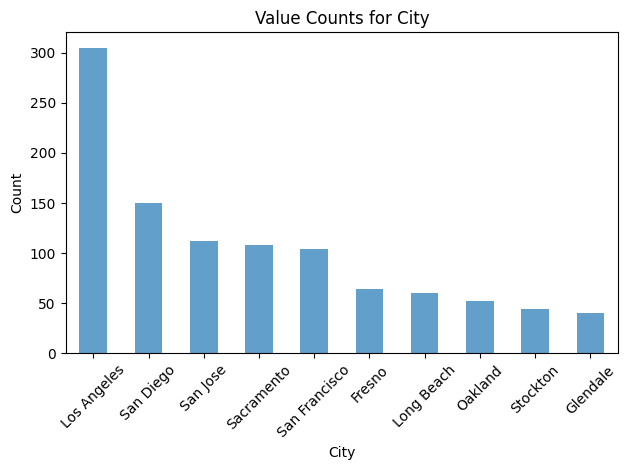

Plotting: Multiple Lines


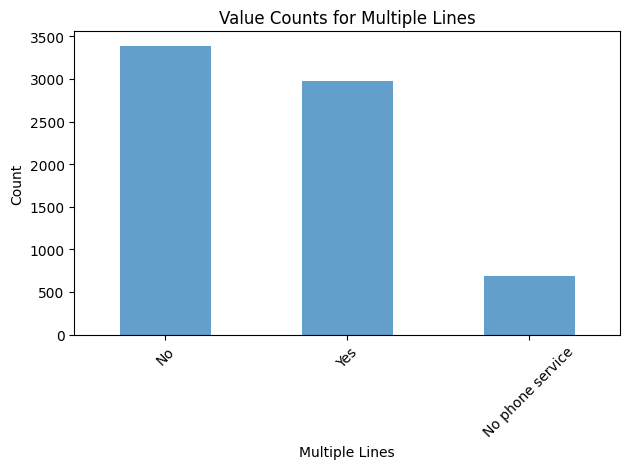

Plotting: Internet Service


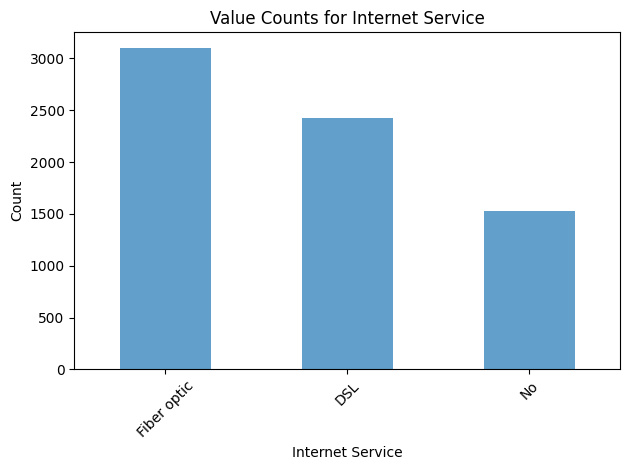

Plotting: Online Security


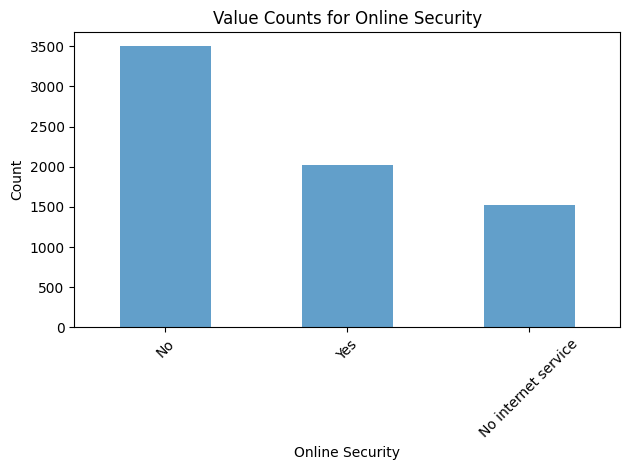

Plotting: Online Backup


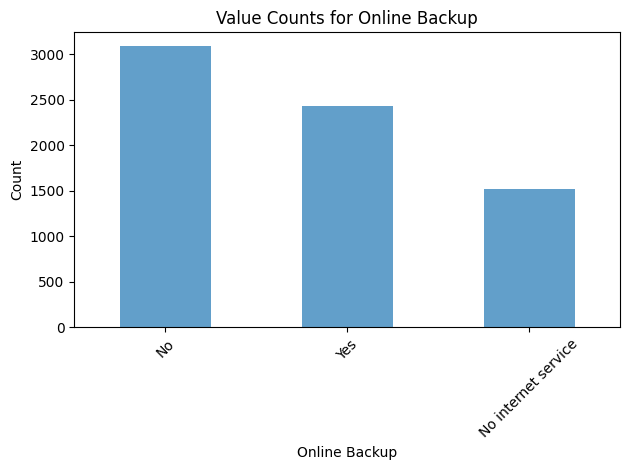

Plotting: Device Protection


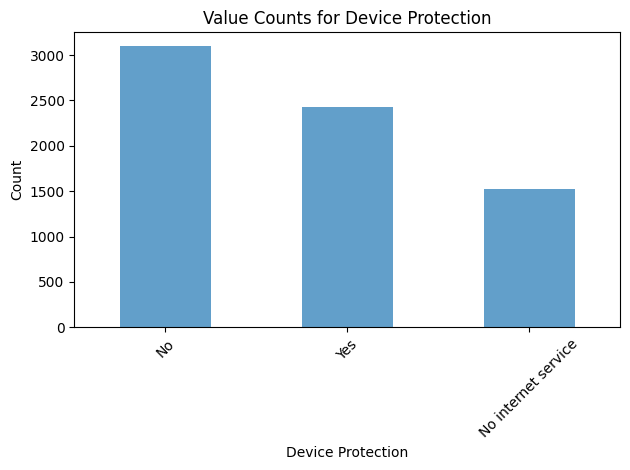

Plotting: Tech Support


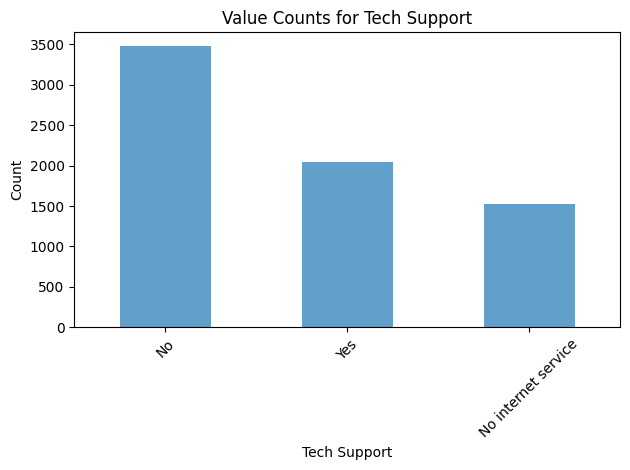

Plotting: Streaming TV


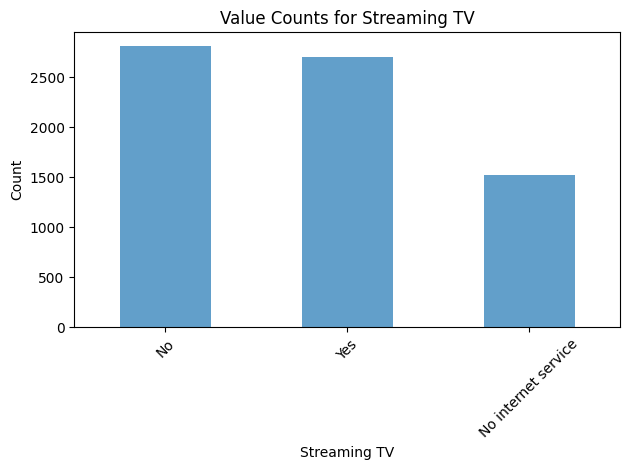

Plotting: Streaming Movies


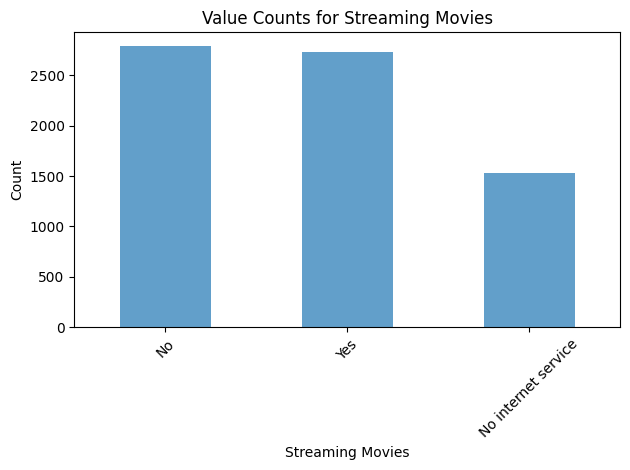

Plotting: Contract


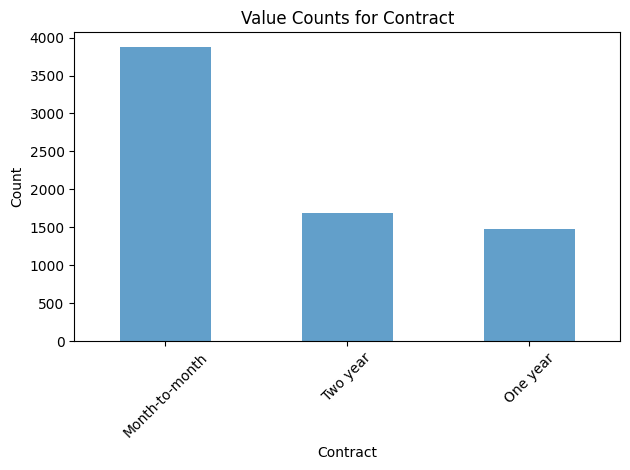

Plotting: Payment Method


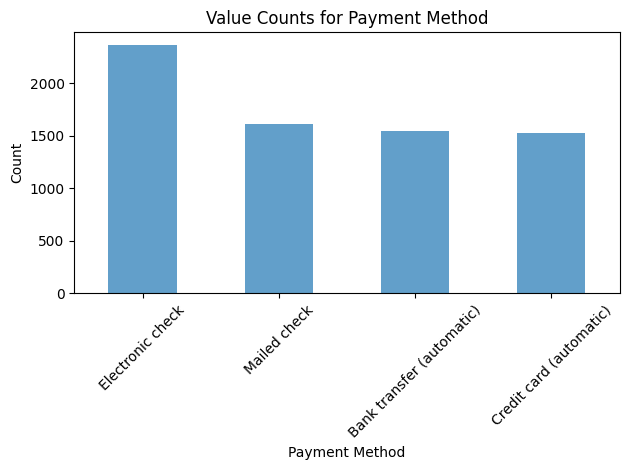

In [6]:
import matplotlib.pyplot as plt

exclude_cols = ['CustomerID', 'Zip Code', 'Lat Long', 'Total Charges', 'Churn Reason']

# select categorical columns
cat_cols = data_df.select_dtypes(include=["string", "category"]).columns

for col in cat_cols:
    if col not in exclude_cols and data_df[col].nunique() > 2:
        print(f"Plotting: {col}")
        
        data_df[col].value_counts().head(10).plot(kind="bar", alpha = 0.7)
        plt.title(f"Value Counts for {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# **Check for 'NaN' values.**

Let's print columns with non-zero counts for 'NaN' values.

In [8]:
nan_counts = data_df.isna().sum()
print(nan_counts[nan_counts > 0])

Churn Reason    5174
dtype: int64


There is only one column with NaN's, called 'Churn Reason'. In this case NaN's can be converted to 'unknown' for modeling.